# Tutorial 08 — Kernels, t-SNE, UMAP e limites da representação

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 8)
torch.manual_seed(SEED + 8)
OUT = ROOT / "estudos" / "tutorial_08" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 8, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260916 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## O que é medido

O toro é $T^2=S^1\times S^1\subset\mathbb R^4$, com coordenadas $(\cos\theta,\sin\theta,\cos\varphi,\sin\varphi)$. Com diferenças angulares mínimas $\delta_1,\delta_2\in[0,\pi]$,
$$d_{\rm int}=\sqrt{\delta_1^2+\delta_2^2},\qquad d_{\rm amb}=\sqrt{4\sin^2(\delta_1/2)+4\sin^2(\delta_2/2)}.$$
A inclusão preserva o tensor métrico infinitesimal, não as distâncias euclidianas entre pares distantes. A esfera é $S^2$ inserida por uma isometria linear em $\mathbb R^{60}$, com ruído de desvio 0.01.

Usamos dois diagnósticos principais do original: fração de 12 vizinhos preservados e correlação de Pearson das distâncias. A função do original chamada `trustworthiness_knn` calcula **overlap/recall de vizinhos**, não o trustworthiness ponderado por ranks. Guardamos o overlap contra a métrica ambiente e contra a intrínseca; as comparações entre métodos usam sempre as mesmas referências.

Acrescentamos uma fração de arestas locais cujo comprimento projetado excede três vezes a mediana: é um diagnóstico de estiramento, **não uma estimativa certificada de topologia**. Os experimentos usam 450 pontos por superfície, três sementes, inicialização aleatória e 750 iterações de t-SNE. O código de UMAP usa o pacote oficial quando instalado; qualquer ausência da dependência é registrada, sem inventar seus resultados.

In [2]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
n=450
th=rng.uniform(0,2*np.pi,n);ph=rng.uniform(0,2*np.pi,n)
T=np.column_stack([np.cos(th),np.sin(th),np.cos(ph),np.sin(ph)])
dth=np.abs(th[:,None]-th[None,:]);dth=np.minimum(dth,2*np.pi-dth)
dph=np.abs(ph[:,None]-ph[None,:]);dph=np.minimum(dph,2*np.pi-dph)
Dint=np.hypot(dth,dph);Damb=distance.squareform(distance.pdist(T))
S2=sphere(1500,3,rng);Q,_=np.linalg.qr(rng.normal(size=(60,3)))
Xs=S2@Q.T+.01*rng.normal(size=(len(S2),60))
Dsi=geodesic(S2[:n]);Dsa=distance.squareform(distance.pdist(Xs[:n]))
lab=rng.integers(0,2,700);r=np.where(lab==0,1.,2.2)+.06*rng.normal(size=700)
Xsh=sphere(700,3,rng)*r[:,None]

# Centrar K por médias evita duas multiplicações densas desnecessárias.
def kpca_gram(K,k=6):
    Kc=K-K.mean(0)[None,:]-K.mean(1)[:,None]+K.mean()
    vals,V=linalg.eigh(Kc,subset_by_index=[len(K)-k,len(K)-1],check_finite=False)
    vals=vals[::-1];V=V[:,::-1]
    return V*np.sqrt(np.maximum(vals,0)),vals

def separation(Y,labels):
    return np.abs(Y[labels==0].mean(0)-Y[labels==1].mean(0))/np.maximum(Y.std(0),1e-12)

def quality(Y,Di,Da):
    result=embed_metrics(Y,Di,k=12)
    result['knn_ambiente']=knn_overlap(Da,distance.squareform(distance.pdist(Y)),12)
    return result

## Exercício 1

> **Exercise 1 — the kernel is the geometry.**
> (a) Sweep $\gamma = 1/2\sigma^2$ over several orders of magnitude and plot the
> separation measured above. Identify the regimes where the kernel is too narrow
> (every point is its own neighbour) and too wide (everything is one blob).
>
> (b) Replace the RBF kernel by the polynomial kernel $k(x,x')=(1+\langle x,x'\rangle)^d$.
> For which $d$ do the shells separate, and can you say why from the shape of the
> feature map? (Hint: what does $\lVert x\rVert^2$ look like in that feature space?)
>
> (c) Apply kernel PCA to the sphere-in-$\mathbb{R}^{60}$ of §1. Does it report
> dimension 2, or still 3? What would you have to compute instead to get 2?

### Resolução

**(a) Largura e degeneração.** Para $\gamma\to0$, $K_{ij}=1-\gamma\|x_i-x_j\|^2+O(\gamma^2)$; após centrar,
$$HKH=2\gamma X_cX_c^T+O(\gamma^2).$$
As componentes dominantes aproximam as lineares, mas componentes de ordem superior podem carregar informação radial com autovalores muito pequenos. Como o score divide pelo desvio da própria componente, um score alto sozinho pode esconder uma direção quase degenerada. Por isso registramos autovalor relativo e peso médio fora da diagonal. Para $\gamma\to\infty$ e pontos distintos, $K\to I$, $HKH\to H$: surgem $N-1$ autovalores iguais e não há uma direção geométrica privilegiada. Um intervalo intermediário pode destacar a diferença de raios.

**(b) Grau 2 já contém o raio quadrado.** A expansão multinomial de $(1+x\cdot x')^d$ contém monômios até grau $d$ com pesos positivos. Para $d\ge2$, $\|x\|^2=x_1^2+x_2^2+x_3^2$ é uma função linear no espaço de características, de modo que cascas de raios distintos podem ser separadas por um limiar nessa função. Isso afirma capacidade de separação no espaço completo, não que a primeira componente de maior variância a exibirá. Registramos o melhor score entre seis componentes e a componente correspondente. Usar o rótulo para escolher a melhor componente é aqui diagnóstico supervisionado **posterior**, não parte de uma descoberta não supervisionada.

**(c) A alternativa “2 ou 3” é incompleta.** PCA linear vê três direções principais da esfera limpa inserida linearmente. Kernel PCA mede variância em outro espaço, que pode ter muitas direções; um RBF em pontos distintos geralmente tem Gram de posto elevado. Na população uniforme, modos esféricos aparecem em blocos de multiplicidade $2\ell+1$, e três modos dominantes podem refletir $\ell=1$, não a dimensão intrínseca. Para obter 2, analisamos espaços tangentes locais: $T_xS^2=\{v\in\mathbb R^3:x\cdot v=0\}$ tem dimensão 2. A PCA de vizinhanças pequenas aproxima esse plano; uma janela grande introduz curvatura e uma janela minúscula com ruído pode ser dominada por ruído. Mostramos as duas versões, limpa e ruidosa.

      gamma  separacao_max  componente  autovalor_relativo   lambda1  media_fora_diagonal
   0.000100       1.984084           4            0.000310  0.140364             0.999421
   0.000215       1.984089           4            0.000668  0.302113             0.998753
   0.000464       1.984101           4            0.001440  0.649527             0.997316
   0.001000       1.984127           4            0.003102  1.393099             0.994232
   0.002154       1.984182           4            0.006684  2.972537             0.987637
   0.004642       1.984296           4            0.014403  6.273119             0.973658
   0.010000       1.984530           4            0.031038 12.932607             0.944570
   0.021544       1.984970           4            0.066831 25.395918             0.886342
   0.046416       1.985643           4            0.143123 45.256424             0.778589
   0.100000       1.985889           4            0.298610 67.578667             0.606845
   0.21544

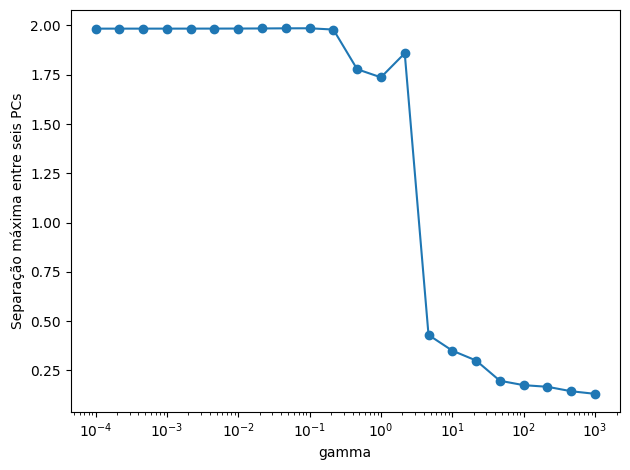

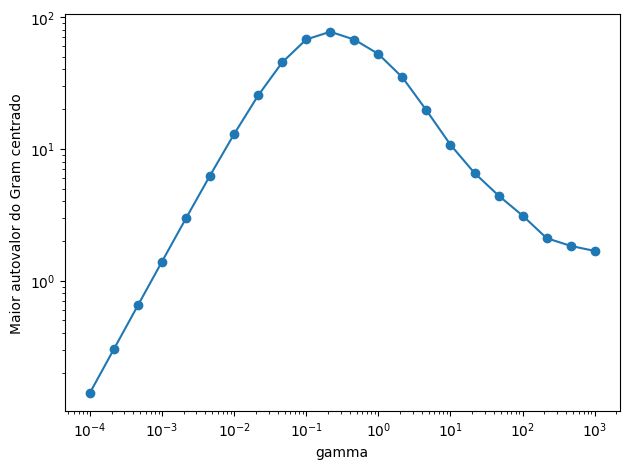

 grau  separacao_max  componente  autovalor_relativo
    1       0.105800           6        3.265554e-16
    2       0.170395           3        9.038451e-01
    3       0.155287           5        3.462306e-01
    4       0.253605           1        1.000000e+00
    5       0.217245           5        5.536268e-01
    6       0.261705           1        1.000000e+00
Separação na característica construída ||x||²: 1.9883062438475188


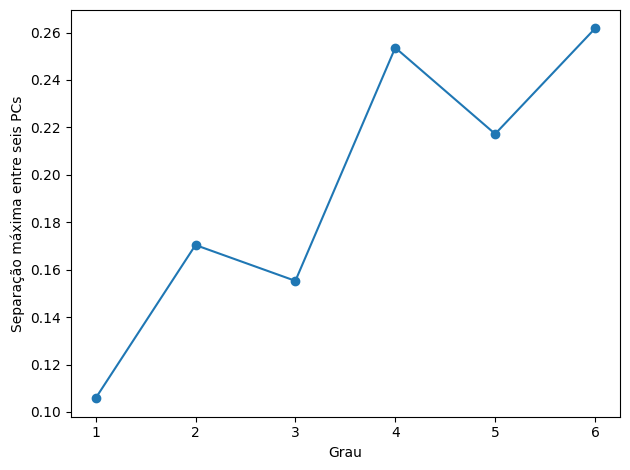

PCA linear: seis variâncias: [3.57700476e-01 3.32542506e-01 3.09347243e-01 1.41177538e-04
 1.36473397e-04 1.34594167e-04]
PCA: fração nas três primeiras: 0.994318790709141


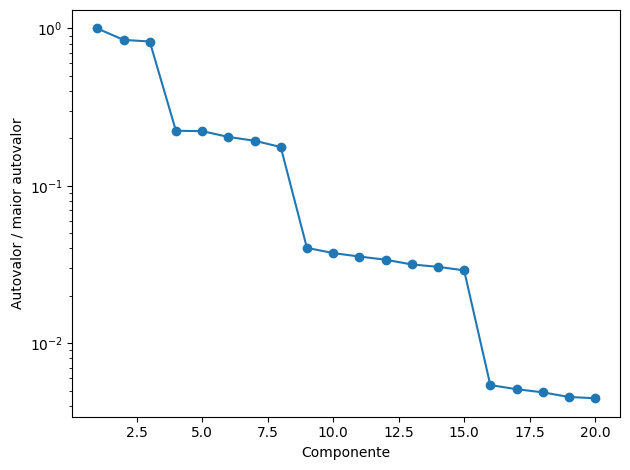

 ruido  k  fracao_2_modos_mediana  razao_lambda2_lambda3_mediana
 False 10                0.998934                     301.853723
 False 20                0.997737                     163.667613
 False 40                0.995706                      98.253149
 False 80                0.991075                      48.654534
  True 10                0.751444                       4.427166
  True 20                0.834584                      14.764409
  True 40                0.901724                      41.012975
  True 80                0.939481                      41.596705


In [3]:
Dsh2=distance.squareform(distance.pdist(Xsh,metric='sqeuclidean'))
rbf=[]
for gamma in np.logspace(-4,3,22):
    K=np.exp(-gamma*Dsh2);Y,vals=kpca_gram(K,6);sep=separation(Y,lab);j=int(sep.argmax())
    rbf.append(dict(gamma=gamma,separacao_max=sep[j],componente=j+1,
                    autovalor_relativo=vals[j]/max(vals[0],1e-15),lambda1=vals[0],
                    media_fora_diagonal=(K.sum()-len(K))/(len(K)*(len(K)-1))))
rbf=table(rbf,'rbf_largura_e_separacao',OUT)
plt.figure();plt.semilogx(rbf.gamma,rbf.separacao_max,marker='o');plt.xlabel('gamma');plt.ylabel('Separação máxima entre seis PCs');figure('kernel_rbf_largura',OUT)
plt.figure();plt.loglog(rbf.gamma,rbf.lambda1,marker='o');plt.xlabel('gamma');plt.ylabel('Maior autovalor do Gram centrado');figure('kernel_rbf_escala',OUT)
polynomial=[]
for d in range(1,7):
    K=(1+Xsh@Xsh.T)**d;Y,vals=kpca_gram(K,6);sep=separation(Y,lab);j=int(sep.argmax())
    polynomial.append(dict(grau=d,separacao_max=sep[j],componente=j+1,autovalor_relativo=vals[j]/vals[0]))
polynomial=table(polynomial,'kernel_polinomial',OUT)
radial_sep=separation(np.sum(Xsh**2,axis=1)[:,None],lab)[0]
print('Separação na característica construída ||x||²:',radial_sep)
plt.figure();plt.plot(polynomial.grau,polynomial.separacao_max,marker='o');plt.xlabel('Grau');plt.ylabel('Separação máxima entre seis PCs');figure('kernel_grau',OUT)

pc=PCA().fit(Xs)
print('PCA linear: seis variâncias:',pc.explained_variance_[:6])
print('PCA: fração nas três primeiras:',pc.explained_variance_ratio_[:3].sum())
Ds2=distance.squareform(distance.pdist(Xs[:700],metric='sqeuclidean'))
Y,ev=kpca_gram(np.exp(-.6*Ds2),20)
plt.figure();plt.semilogy(np.arange(1,21),ev/ev[0],marker='o');plt.xlabel('Componente');plt.ylabel('Autovalor / maior autovalor');figure('kpca_esfera_espectro',OUT)
local=[]
for noisy in [False,True]:
    X=Xs if noisy else S2@Q.T
    for k in [10,20,40,80]:
        idx=cKDTree(X).query(X[:200],k=k)[1];fractions=[];ratios=[]
        for indices in idx:
            Z=X[indices]-X[indices].mean(0);sv=np.linalg.svd(Z,compute_uv=False)**2
            fractions.append(sv[:2].sum()/sv.sum());ratios.append(sv[1]/max(sv[2],1e-15))
        local.append(dict(ruido=noisy,k=k,fracao_2_modos_mediana=np.median(fractions),razao_lambda2_lambda3_mediana=np.median(ratios)))
local=table(local,'dimensao_tangente_local',OUT)

## Exercício 2

> **Exercise 2 — stress-test the picture.**
> (a) The clusters above were the easy case, and every run agreed. Do the same on the
> torus, where they will not: re-run at perplexities $5, 30, 100$ with three seeds
> each, and say which features survive all nine runs. With no labels to compute purity
> from, what do you use in its place?
>
> (b) Feed t-SNE the **intrinsic** distance matrix `D_sub_int` instead of the
> ambient one. The tear should remain (topology), but the local geometry should
> improve — measure both claims.
>
> (c) Compute the two diagnostics above for a range of perplexities and plot the
> trade-off between neighbourhood preservation and global-distance correlation.
> There is no setting that maximises both; explain why in terms of the KL objective.

### Resolução

**(a) Nove execuções e estabilidade.** Rodamos perplexidades 5, 30 e 100, com sementes 0, 1 e 2. Sem classes verdadeiras, usamos preservação de vizinhos da geometria conhecida, correlação de distâncias e estabilidade das vizinhanças projetadas entre execuções. Também calculamos a fração de vizinhos intrínsecos preservada **em todas as nove** execuções. Uma ilha visual recorrente não prova a existência de uma componente: o toro é conectado. Cores por $\theta$ e $\varphi$ ajudam a localizar misturas e descontinuidades aparentes, mas as conclusões são apoiadas pelas tabelas.

**(b) Trocar a métrica não elimina a obstrução.** Repetimos as nove execuções com distâncias intrínsecas e comparamos pares de mesma perplexidade/semente usando a mesma referência intrínseca. Não é um teorema que toda métrica “mais verdadeira” produza maior overlap após um otimizador não convexo.

Uma superfície compacta sem bordo não admite aplicação contínua e injetiva em $\mathbb R^2$: por invariância do domínio, a imagem teria de ser aberta, enquanto a compactação exige imagem compacta. Portanto, uma representação global precisa perder injetividade, continuidade ou alguma outra exigência de fidelidade; ela pode **sobrepor**, não necessariamente “rasgar” como um corte desenhado. Uma nuvem finita, porém, pode ser injetada no plano, pois não é a superfície inteira. Nossa fração de arestas estiradas mede dano local no grafo, não prova esse teorema para o mapa aprendido.

**(c) Objetivo e trade-off.** t-SNE minimiza $\mathrm{KL}(P\|Q)=\sum_{ij}p_{ij}\log(p_{ij}/q_{ij})$. Pairs com grande $p_{ij}$ pesam mais; representar vizinhos de entrada muito distantes no mapa é penalizado, mas não há uma parcela exigindo preservar todas as distâncias geodésicas globalmente. A perplexidade altera a escala de $P$, não adiciona uma garantia global. O gráfico pode exibir um compromisso entre as duas métricas, mas a afirmação do enunciado “nenhuma configuração maximiza ambas” **não é um teorema geral**: em uma grade finita, o mesmo ponto pode maximizar os dois scores. Testamos isso diretamente e registramos o que acontece.

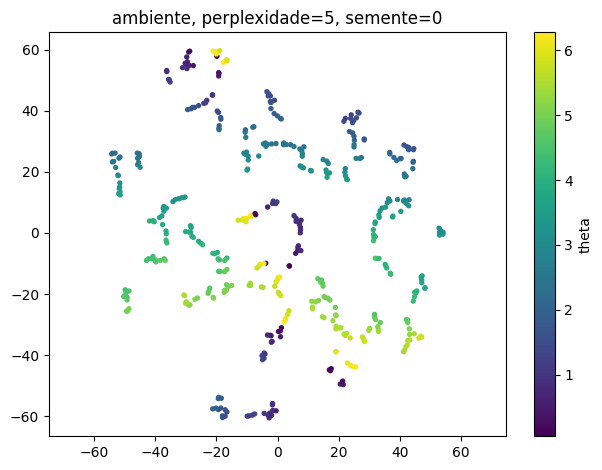

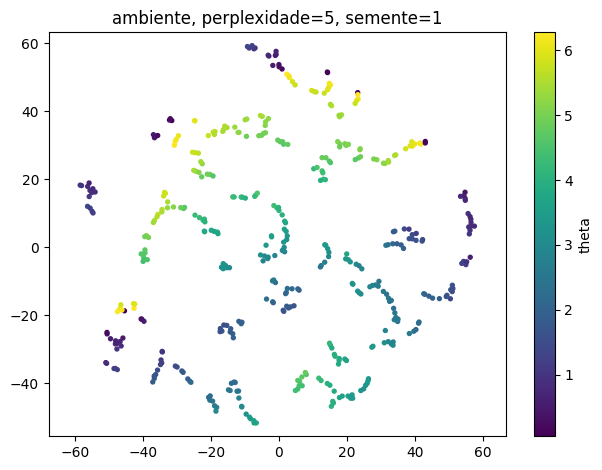

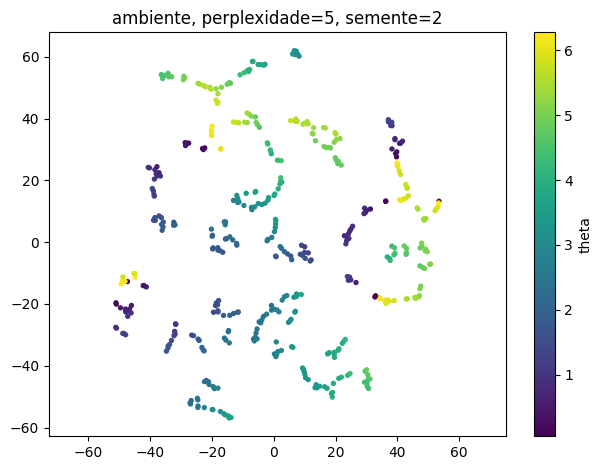

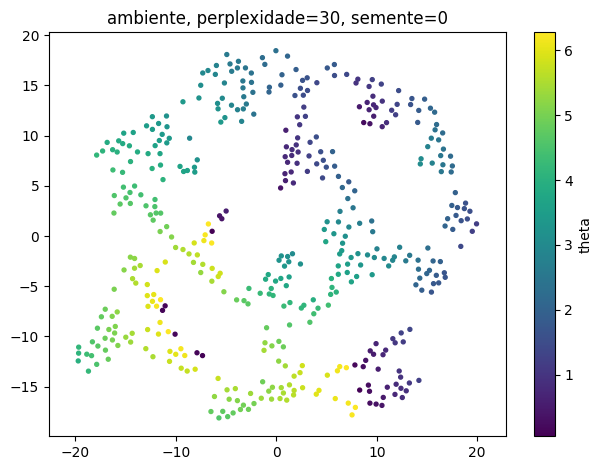

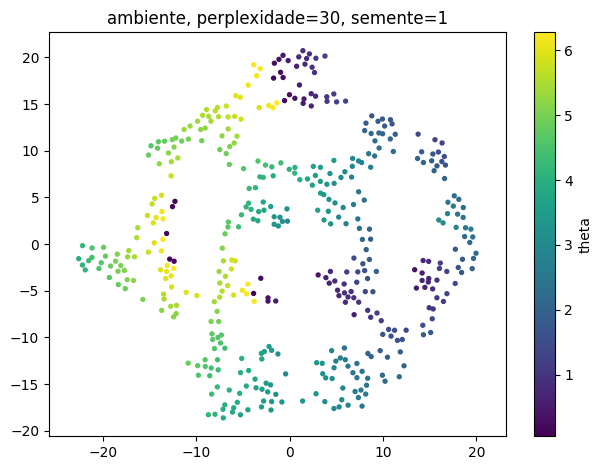

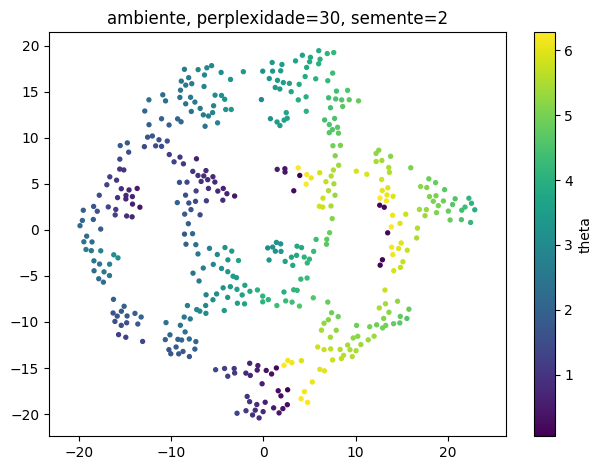

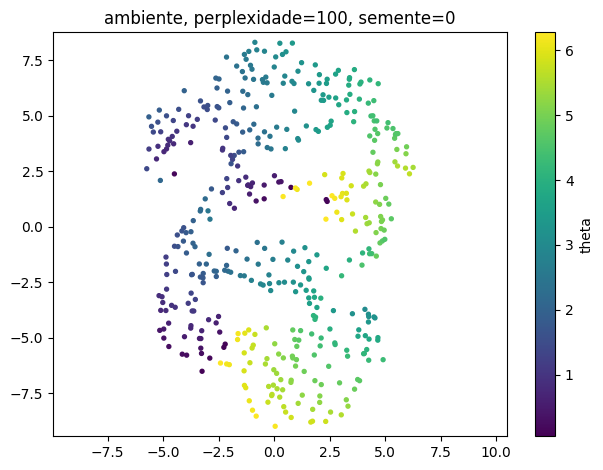

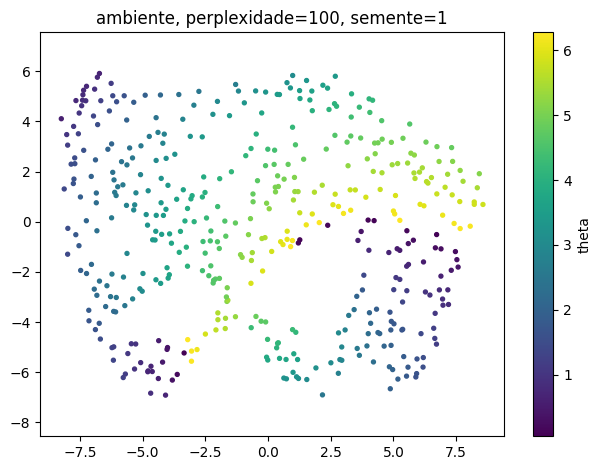

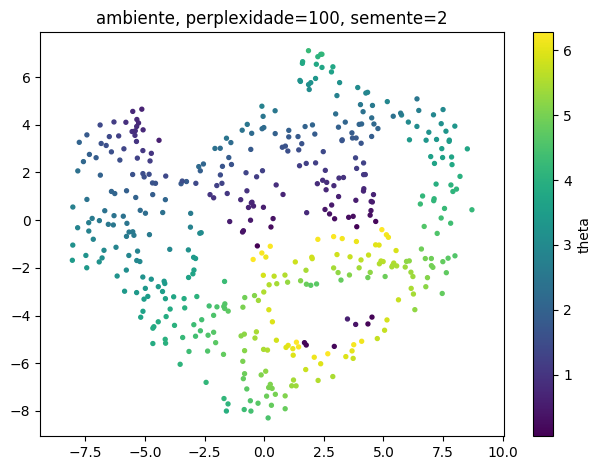

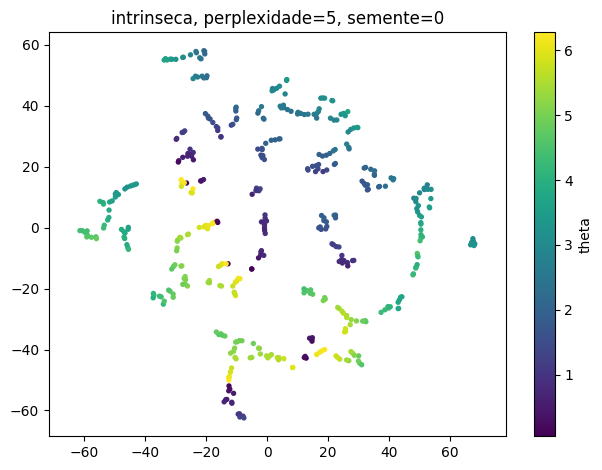

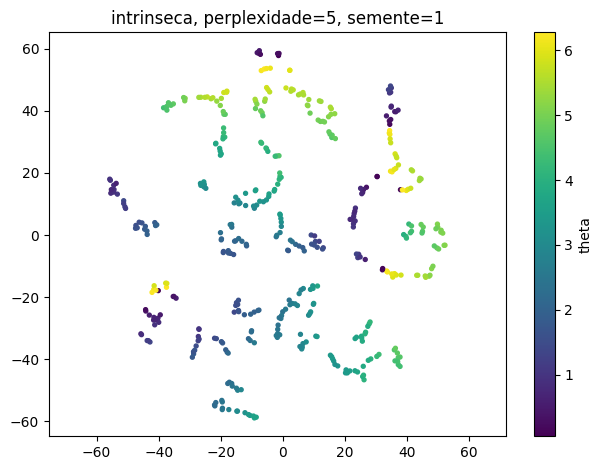

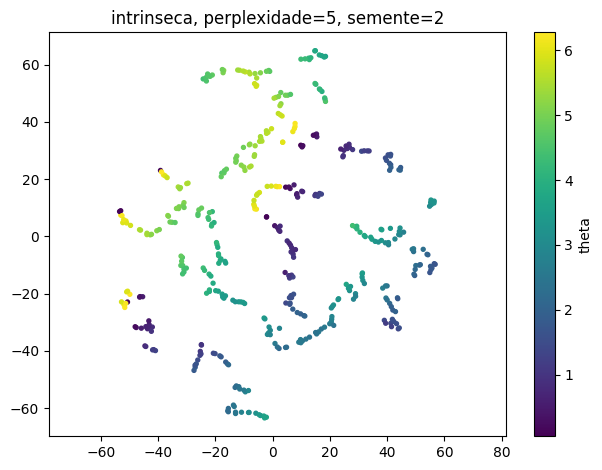

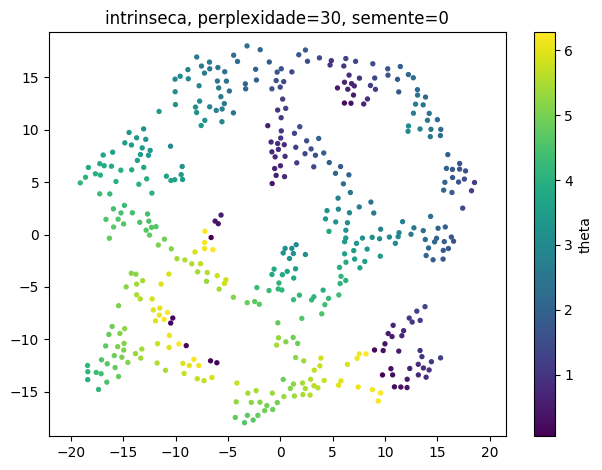

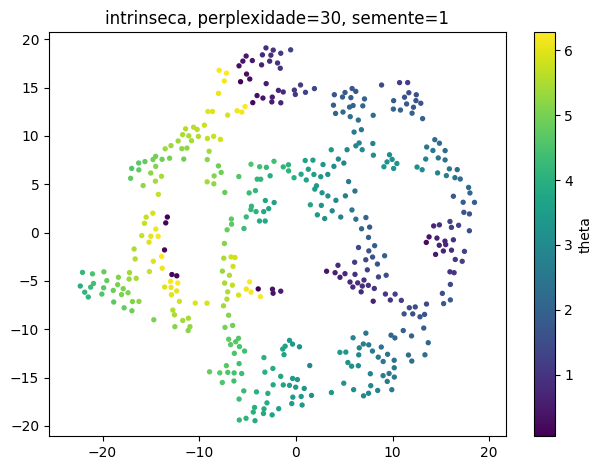

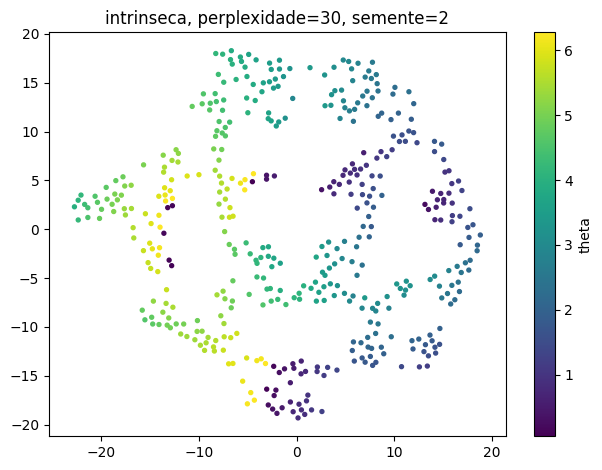

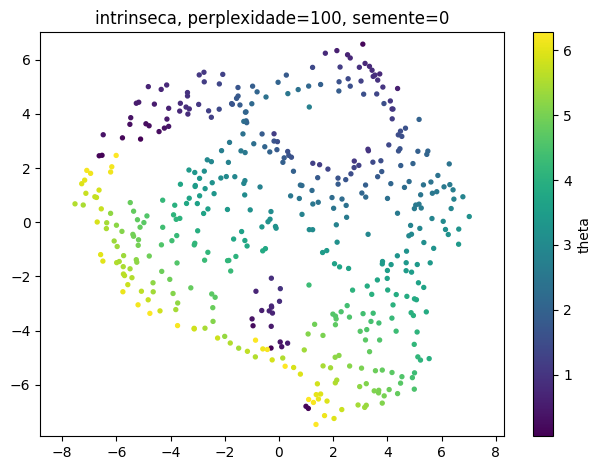

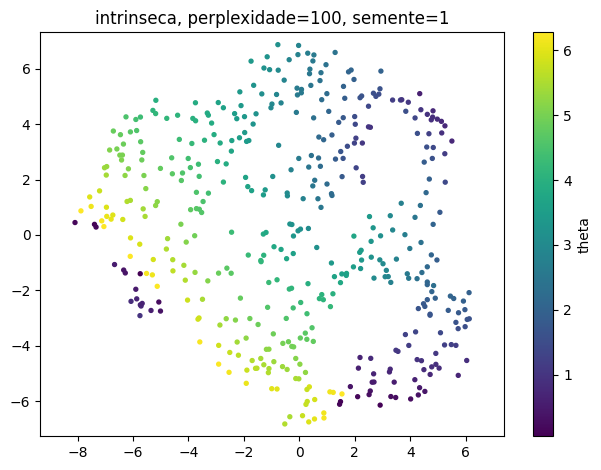

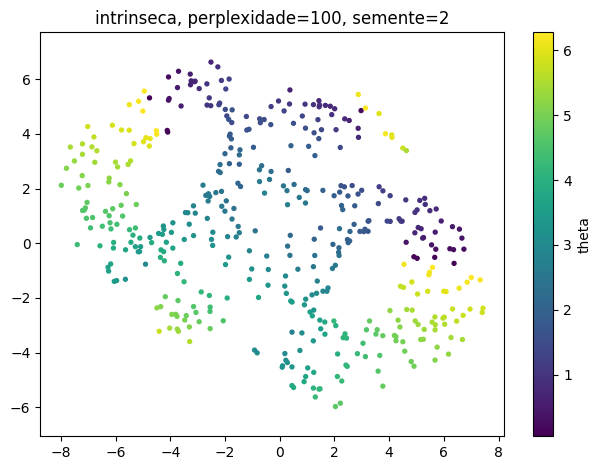

metodo    entrada  perplexidade  semente       KL  knn_preservado  correlacao_global  fracao_arestas_estiradas  knn_ambiente
 t-SNE   ambiente             5        0 0.522020        0.720185           0.461237                  0.164630      0.720185
 t-SNE   ambiente             5        1 0.518004        0.721481           0.564598                  0.136296      0.722407
 t-SNE   ambiente             5        2 0.520200        0.712963           0.532143                  0.152037      0.713148
 t-SNE   ambiente            30        0 0.680239        0.788889           0.627349                  0.109074      0.789815
 t-SNE   ambiente            30        1 0.683259        0.788704           0.631491                  0.110926      0.789444
 t-SNE   ambiente            30        2 0.683065        0.788519           0.630794                  0.111481      0.789074
 t-SNE   ambiente           100        0 0.530507        0.748333           0.614656                  0.087222      0.748889


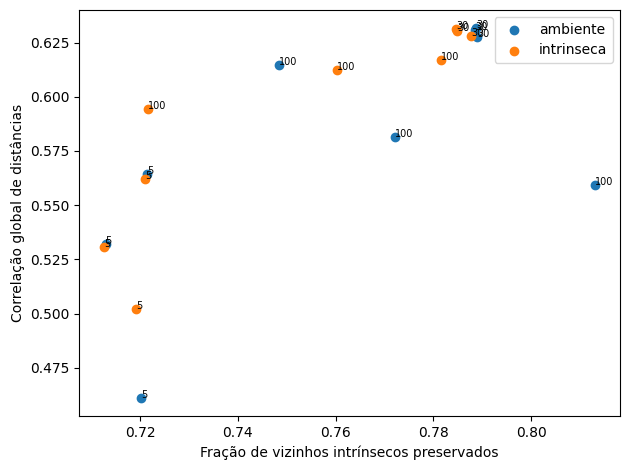

Mesma execução maximiza os dois diagnósticos nesta grade? False
Maximizador local: {'entrada': 'ambiente', 'perplexidade': 100, 'semente': 1}
Maximizador global: {'entrada': 'ambiente', 'perplexidade': 30, 'semente': 1}


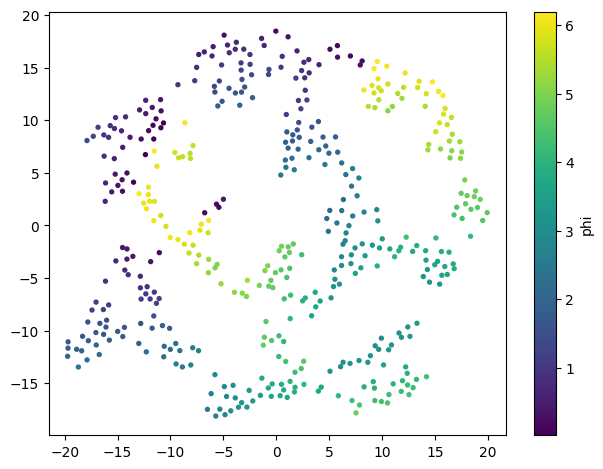

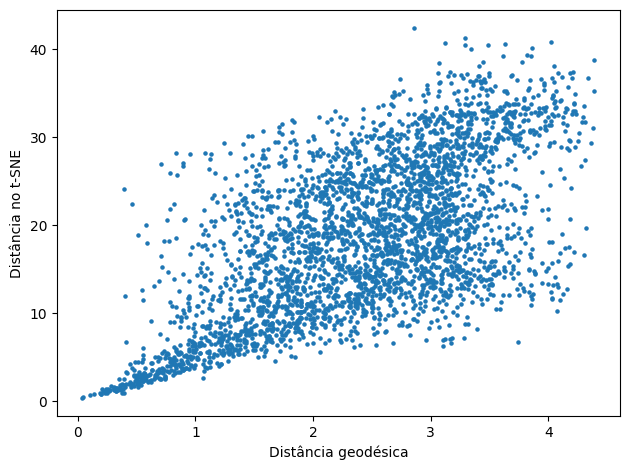

In [4]:
records=[];embeddings={};neighbor_masks={}
for input_metric,Dinput in [('ambiente',Damb),('intrinseca',Dint)]:
    for perplexity in [5,30,100]:
        for seed in [0,1,2]:
            ts=TSNE(n_components=2,perplexity=perplexity,metric='precomputed',init='random',
                    learning_rate='auto',max_iter=750,random_state=seed,method='barnes_hut',n_jobs=1)
            Y=ts.fit_transform(Dinput)
            key=(input_metric,perplexity,seed);embeddings[key]=Y
            row=dict(metodo='t-SNE',entrada=input_metric,perplexidade=perplexity,semente=seed,KL=ts.kl_divergence_,**quality(Y,Dint,Damb))
            records.append(row)
            np.savetxt(OUT/f'toro_{input_metric}_p{perplexity}_s{seed}.csv',np.column_stack([Y,th,ph]),delimiter=',',header='y1,y2,theta,phi',comments='')
            projected=distance.squareform(distance.pdist(Y));near=np.argsort(projected,axis=1)[:,1:13]
            mask=np.zeros((n,n),dtype=bool);mask[np.arange(n)[:,None],near]=True;neighbor_masks[key]=mask
            plt.figure();plt.scatter(*Y.T,c=th,s=8);plt.colorbar(label='theta');plt.axis('equal')
            plt.title(f'{input_metric}, perplexidade={perplexity}, semente={seed}');figure(f'toro_{input_metric}_p{perplexity}_s{seed}',OUT)
records=table(records,'tsne_18_execucoes',OUT)
true_near=np.argsort(Dint,axis=1)[:,1:13];true_mask=np.zeros((n,n),dtype=bool)
true_mask[np.arange(n)[:,None],true_near]=True
stable=[]
for input_metric,df in records.groupby('entrada'):
    all_masks=[neighbor_masks[(input_metric,p,s)] for p in [5,30,100] for s in [0,1,2]]
    intersection=np.logical_and.reduce(all_masks)
    stable.append(dict(entrada=input_metric,knn_intrinseco_min=df.knn_preservado.min(),knn_intrinseco_max=df.knn_preservado.max(),
                       correlacao_min=df.correlacao_global.min(),correlacao_max=df.correlacao_global.max(),
                       vizinhos_verdadeiros_em_todas=np.sum(intersection&true_mask)/(n*12)))
stable=table(stable,'estabilidade_nove_execucoes',OUT)
paired=records[records.entrada=='intrinseca'].set_index(['perplexidade','semente'])[
    ['knn_preservado','correlacao_global','fracao_arestas_estiradas']]-records[records.entrada=='ambiente'].set_index(['perplexidade','semente'])[
    ['knn_preservado','correlacao_global','fracao_arestas_estiradas']]
paired=table(paired.reset_index(),'diferenca_intrinseca_menos_ambiente',OUT)
print('Diferenças médias:',paired[['knn_preservado','correlacao_global','fracao_arestas_estiradas']].mean().to_dict())
plt.figure()
for metric,df in records.groupby('entrada'):
    plt.scatter(df.knn_preservado,df.correlacao_global,label=metric)
    for _,row in df.iterrows():plt.annotate(str(int(row.perplexidade)),(row.knn_preservado,row.correlacao_global),fontsize=7)
plt.xlabel('Fração de vizinhos intrínsecos preservados');plt.ylabel('Correlação global de distâncias');plt.legend();figure('tradeoff_tsne',OUT)
a=records.knn_preservado.idxmax();c=records.correlacao_global.idxmax()
print('Mesma execução maximiza os dois diagnósticos nesta grade?',a==c)
print('Maximizador local:',records.loc[a,['entrada','perplexidade','semente']].to_dict())
print('Maximizador global:',records.loc[c,['entrada','perplexidade','semente']].to_dict())
# Mesma projeção, outra coloração e distâncias: uma figura para cada diagnóstico.
Y=embeddings[('ambiente',30,0)]
plt.figure();plt.scatter(*Y.T,c=ph,s=8);plt.colorbar(label='phi');plt.axis('equal');figure('toro_colorido_phi',OUT)
iu=np.triu_indices(n,1);DY=distance.squareform(distance.pdist(Y))
plt.figure();plt.scatter(Dint[iu][::30],DY[iu][::30],s=5);plt.xlabel('Distância geodésica');plt.ylabel('Distância no t-SNE');figure('distorcao_global_tsne',OUT)

## Exercício 3

> **Exercise 3 — UMAP, and a fair comparison.**
> Install `umap-learn` (`pip install umap-learn`) and embed the same torus. UMAP
> optimises a different objective built from a fuzzy simplicial complex, and it is
> usually claimed to preserve global structure better. Test that claim with the same
> two numbers rather than by eye. Then try both methods on the sphere of §1, where
> you know the answer, before trusting either on data where you do not.

### Resolução

**Resolução: protocolo de comparação e critério de resposta.** Construímos embeddings de UMAP para os *mesmos* 450 pontos do toro, com `n_neighbors=5,30,100`, três sementes e `min_dist=0.1`; as matrizes de entrada são as mesmas de t-SNE. Repetimos nas mesmas 450 amostras da esfera. Há uma referência PCA de duas componentes para ambas. Não equiparamos numericamente `n_neighbors` a perplexidade como se fossem o mesmo parâmetro; comparamos faixas e dispersão, sem selecionar um único desenho favorável.

UMAP atribui pesos locais a vizinhanças e combina os grafos direcionados por união fuzzy; ajusta uma representação de baixa dimensão por um objetivo de entropia cruzada. Nenhuma dessas etapas é uma garantia de isometria global. O critério operacional para a alegação “preserva melhor o global” é uma correlação intrínseca maior **sem esconder o score local**, reproduzida em várias sementes e nas duas superfícies. Resultados diferentes por superfície ou parâmetro refutam uma formulação universal da alegação.

Na esfera sabemos previamente que a dimensão intrínseca é 2 e que uma única carta planar contínua e injetiva não cobre toda a superfície. Assim, uma figura plana com uma aparente borda, sobreposição ou separação não altera a topologia verdadeira. Não usamos a aparência de uma ilha como rótulo.

**Estado da execução desta entrega:** o bloco abaixo tenta importar o pacote oficial. Quando ele não está instalado, os resultados de UMAP ficam explicitamente ausentes e `estado_umap.json` registra a pendência; os resultados da esfera com t-SNE e PCA continuam sendo calculados. O código de UMAP não é substituído por outra implementação nem por números exemplificativos. Após instalar as dependências do repositório, executar novamente o caderno gera todas as tabelas de comparação. Enquanto isso, **não há conclusão empírica t-SNE × UMAP nesta cópia**.

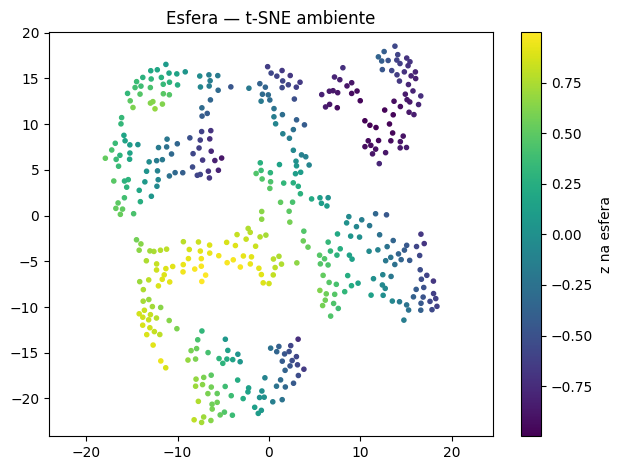

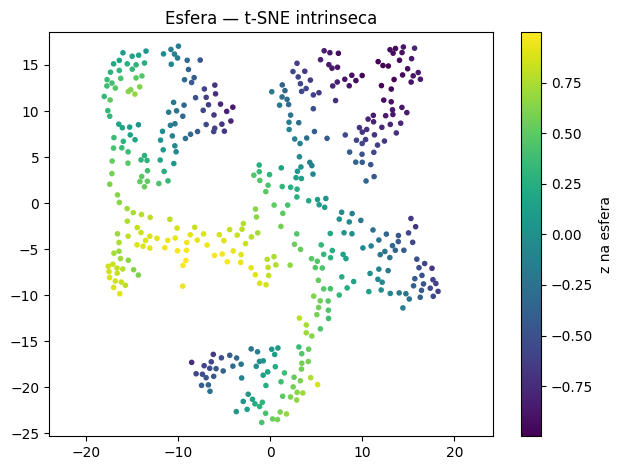

UMAP NÃO EXECUTADO. Nenhum número foi imputado ou inventado.
superficie metodo    entrada  escala  semente  knn_preservado  correlacao_global  fracao_arestas_estiradas  knn_ambiente
      toro    PCA   ambiente       0        0        0.461667           0.663718                  0.000000      0.461481
      toro  t-SNE   ambiente       5        0        0.720185           0.461237                  0.164630      0.720185
      toro  t-SNE   ambiente       5        1        0.721481           0.564598                  0.136296      0.722407
      toro  t-SNE   ambiente       5        2        0.712963           0.532143                  0.152037      0.713148
      toro  t-SNE   ambiente      30        0        0.788889           0.627349                  0.109074      0.789815
      toro  t-SNE   ambiente      30        1        0.788704           0.631491                  0.110926      0.789444
      toro  t-SNE   ambiente      30        2        0.788519           0.630794            

In [5]:
fair=[]
for surface,X,Di,Da in [('toro',T,Dint,Damb),('esfera',Xs[:n],Dsi,Dsa)]:
    Y=PCA(n_components=2).fit_transform(X)
    fair.append(dict(superficie=surface,metodo='PCA',entrada='ambiente',escala=0,semente=0,**quality(Y,Di,Da)))
    for metric,DD in [('ambiente',Da),('intrinseca',Di)]:
        for scale in [5,30,100]:
            for seed in [0,1,2]:
                if surface=='toro':Y=embeddings[(metric,scale,seed)]
                else:
                    Y=TSNE(n_components=2,perplexity=scale,metric='precomputed',init='random',learning_rate='auto',
                           max_iter=750,random_state=seed,n_jobs=1).fit_transform(DD)
                    np.savetxt(OUT/f'esfera_tsne_{metric}_p{scale}_s{seed}.csv',Y,delimiter=',',header='y1,y2',comments='')
                    if scale==30 and seed==0:
                        plt.figure();plt.scatter(*Y.T,c=S2[:n,2],s=9);plt.colorbar(label='z na esfera');plt.axis('equal')
                        plt.title('Esfera — t-SNE '+metric);figure('esfera_tsne_'+metric,OUT)
                fair.append(dict(superficie=surface,metodo='t-SNE',entrada=metric,escala=scale,semente=seed,**quality(Y,Di,Da)))
try:
    import umap
except ImportError as exc:
    umap=None
    state=dict(status='NAO_EXECUTADO',etapa='Tutorial 08, exercício 3: experimentos UMAP',
               motivo='umap-learn não disponível no ambiente; instalação externa não concluída.',
               acao='Instale requirements.txt e execute novamente: python executar.py 8',
               detalhe=str(exc))
    print('UMAP NÃO EXECUTADO. Nenhum número foi imputado ou inventado.')
else:
    for surface,X,Di,Da in [('toro',T,Dint,Damb),('esfera',Xs[:n],Dsi,Dsa)]:
        for metric,DD in [('ambiente',Da),('intrinseca',Di)]:
            for neighbors in [5,30,100]:
                for seed in [0,1,2]:
                    model=umap.UMAP(n_neighbors=neighbors,n_components=2,min_dist=.1,metric='precomputed',
                                    random_state=seed,n_jobs=1,n_epochs=500)
                    Y=model.fit_transform(DD)
                    fair.append(dict(superficie=surface,metodo='UMAP',entrada=metric,escala=neighbors,semente=seed,**quality(Y,Di,Da)))
                    np.savetxt(OUT/f'{surface}_umap_{metric}_k{neighbors}_s{seed}.csv',Y,delimiter=',',header='y1,y2',comments='')
                    if neighbors==30 and seed==0:
                        plt.figure();plt.scatter(*Y.T,c=th if surface=='toro' else S2[:n,2],s=9);plt.colorbar();plt.axis('equal')
                        plt.title(surface+' — UMAP '+metric);figure(surface+'_umap_'+metric,OUT)
    state=dict(status='EXECUTADO',etapa='Tutorial 08, exercício 3: experimentos UMAP',versao=umap.__version__)
(OUT/'estado_umap.json').write_text(json.dumps(state,indent=2,ensure_ascii=False),encoding='utf-8')
fair=table(fair,'comparacao_metodos_superficies',OUT)
means=table(fair.groupby(['superficie','metodo','entrada'])[['knn_preservado','knn_ambiente','correlacao_global','fracao_arestas_estiradas']].agg(['mean','std']).reset_index(),
            'comparacao_medias_e_dispersao',OUT)
if umap is not None:
    print('Diferença da correlação global média UMAP−t-SNE, agregada sobre a grade:')
    z=fair.groupby(['superficie','entrada','metodo']).correlacao_global.mean().unstack()
    print(z['UMAP']-z['t-SNE'])
write_summary(OUT.parent/'README.md',
 'medir o que embeddings preservam e distorcem.',
 'dimensão intrínseca, dimensão linear e fidelidade global são perguntas distintas.',
 'Comparei kernels, 18 execuções de t-SNE no toro e 18 na esfera, com métricas fixas.',
 f'No toro, o overlap intrínseco de t-SNE variou de {records.knn_preservado.min():.1%} a {records.knn_preservado.max():.1%}.',
 'A comparação com UMAP está codificada, mas não executada sem a dependência.' if umap is None else 'Nenhum dos diagnósticos certifica a topologia do objeto original.')